In [2]:
import h5py
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pyl
import pywt
import pandas as pd

from cea.signal1D import*
from cea.general import*
from cea.data_loader import*
from cea.output import*

# Ondelettes 1D

Cas classique du signale s:

- rellement continue tel que s(t)
- discretisé sous forme s[t]

Ici on peut appliquer la [DWT](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html) (Discret Wavelet Transform).

Ici je voudrais aussi regarder les difference entre wavelet orthogonales et biorthogonales en plus de leur caracteristique mathématiques,
| Propriété | Orthogonale | Biorthogonale |
| ----------- | ----------- | ----------- |
| énergie conservée | oui | non |
| symétrie | non | oui |
| filtres identiques| oui | non |

Pour ce faire j'aimerais comparer différente [familles des wavelets](https://pywavelets.readthedocs.io/en/latest/ref/wavelets.html) et faire des visualisation comme dans la documentation sur la [CWT](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html)
(Continuous Wavelet Transofrm)

Liste apriori des wavelet interessantes pour ce probleme,
| Orthogonale | Biorthogonale |
| ----------- | ----------- |
| dataN | biorX.Y |
| symN | rbioX.Y |
| haar (data1) | |
| dmey | |


In [3]:
wavelets_list = [
    "haar",
    "db8",
    "sym6",
    "sym8",
    "coif3",
    "bior4.4"
]

# wavelets_list = pywt.wavelist('bior')
print(wavelets_list)

['haar', 'db8', 'sym6', 'sym8', 'coif3', 'bior4.4']


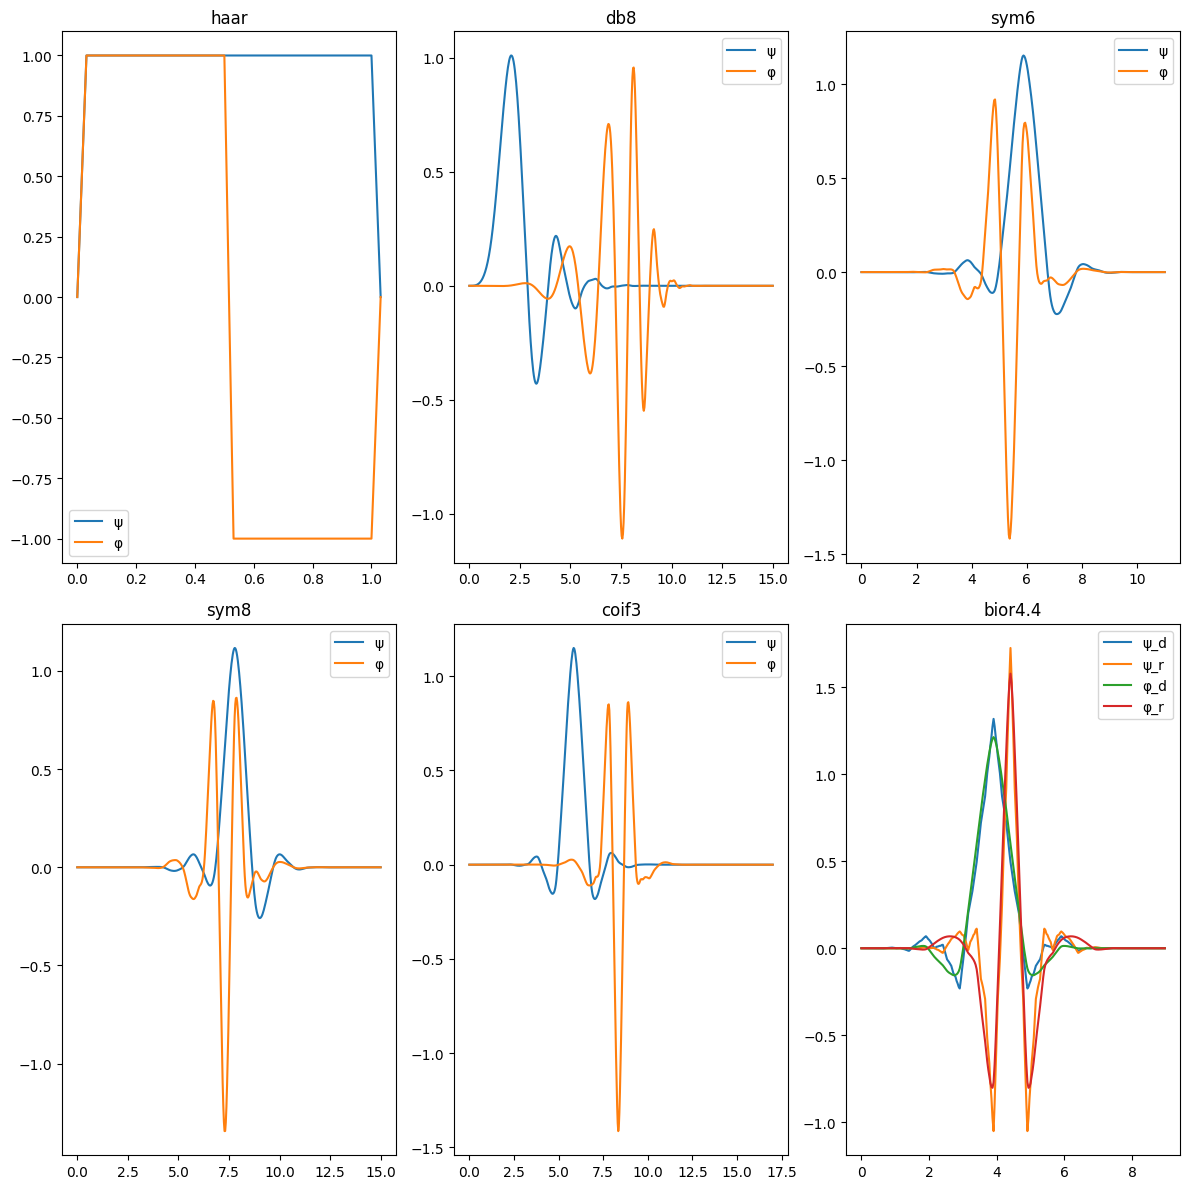

In [4]:
cols = 3
rows = (len(wavelets_list) + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(12, 6 * rows),
                        sharex=False, sharey=False)

axs = np.array(axs).flatten()

for ax, wname in zip(axs, wavelets_list):

    wavelet = pywt.Wavelet(wname)

    # wavefun renvoie scaling function + wavelet function
    result = wavelet.wavefun(level=5)

    if len(result) == 2:
        psi, x = result
        ax.plot(x, psi, label="ψ")

    elif len(result) == 3:
        psi, phi, x = result
        ax.plot(x, psi, label="ψ")
        ax.plot(x, phi, label="φ")

    elif len(result) == 5:
        psi_d, psi_r, phi_d, phi_r, x = result
        ax.plot(x, psi_d, label="ψ_d")
        ax.plot(x, psi_r, label="ψ_r")
        ax.plot(x, phi_d, label="φ_d")
        ax.plot(x, phi_r, label="φ_r")

    else:
        raise ValueError(f"Format unknown for {wavelet.name}")

    ax.set_title(wname)
    ax.legend()

# cacher axes inutiles
for ax in axs[len(wavelets_list):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Application sur un signale

In [5]:
data, labels = load_RTCEA("data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)
idxs = atwood[0.3]
sim = data[idxs,:,:] 

In [6]:
x = sim.shape[2]//2
img= sim[sim.shape[0]-1,:,:] # la derniere image du fichier
sig = img[:,x]

atwood = labels[sim.shape[0]-1,0]
time   = labels[sim.shape[0]-1,1]

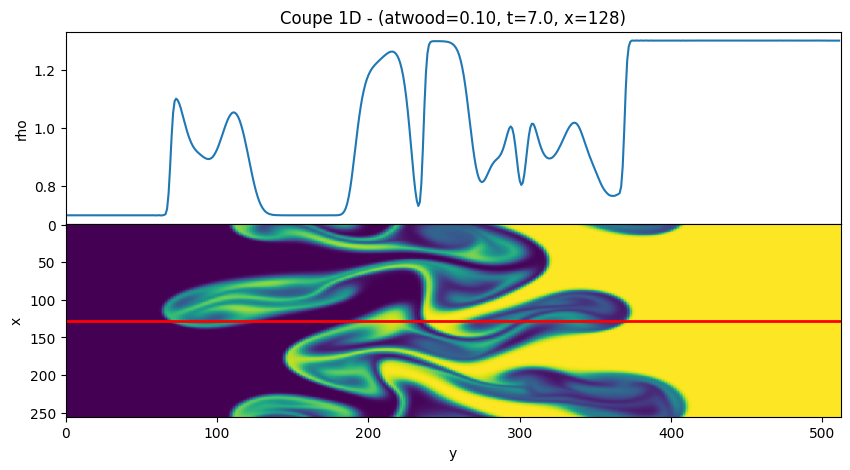

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(sig)
ax[0].set_xlim(0, sim.shape[1])
ax[0].set_title(f'Coupe 1D - (atwood={atwood:.2f}, t={time:.1f}, x={x})')
ax[0].set_ylabel("rho")

ax[1].imshow(img.T, interpolation='nearest', aspect='auto')
ax[1].axhline(y=sim.shape[2]//2, color='red', linewidth=2)
ax[1].set_xlabel("y")
ax[1].set_ylabel("x")

fig.subplots_adjust(hspace=0)
plt.show()

In [8]:
M = 6
wavelet = "haar"
wr = wavelet_non_lineaire(sig, M, wavelet)

Lors de la reconstruction **wf = wf + wi** correspondant a

$$f_M(t) = \sum_{ i \in I_M }c_i\cdot \psi_i(t).$$

**wi** correspond a $c_i\cdot \psi_i(t)$ pas besoins de le multiplier par $c_i

> Numeriquement il faut garder les coefficient et leur index ainsi que la taille de l'espace de base pour pouvoir faire la transformé inverse (liste complète de coeffs avec des zéros partout sauf là où tu veux)


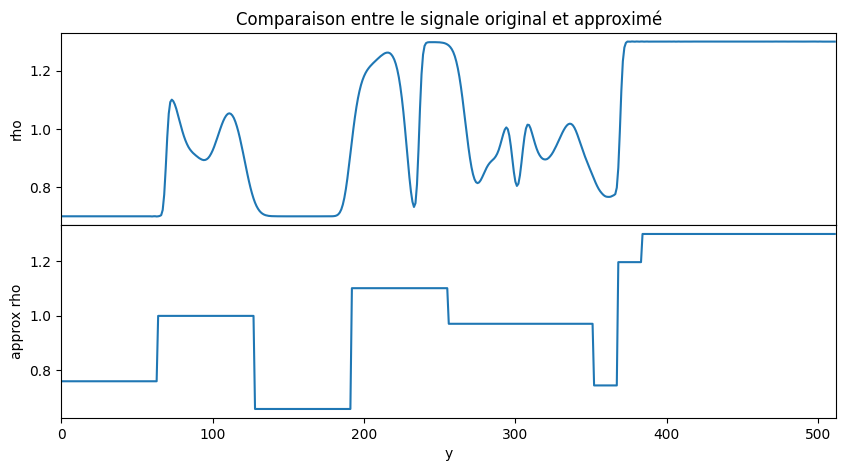

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(sig)
ax[0].set_xlim(0, sim.shape[1])
ax[0].set_title(f'Comparaison entre le signale original et approximé')
ax[0].set_ylabel("rho")

ax[1].plot(wr)
ax[1].set_xlabel("y")
ax[1].set_ylabel("approx rho")

fig.subplots_adjust(hspace=0)
plt.show()

512


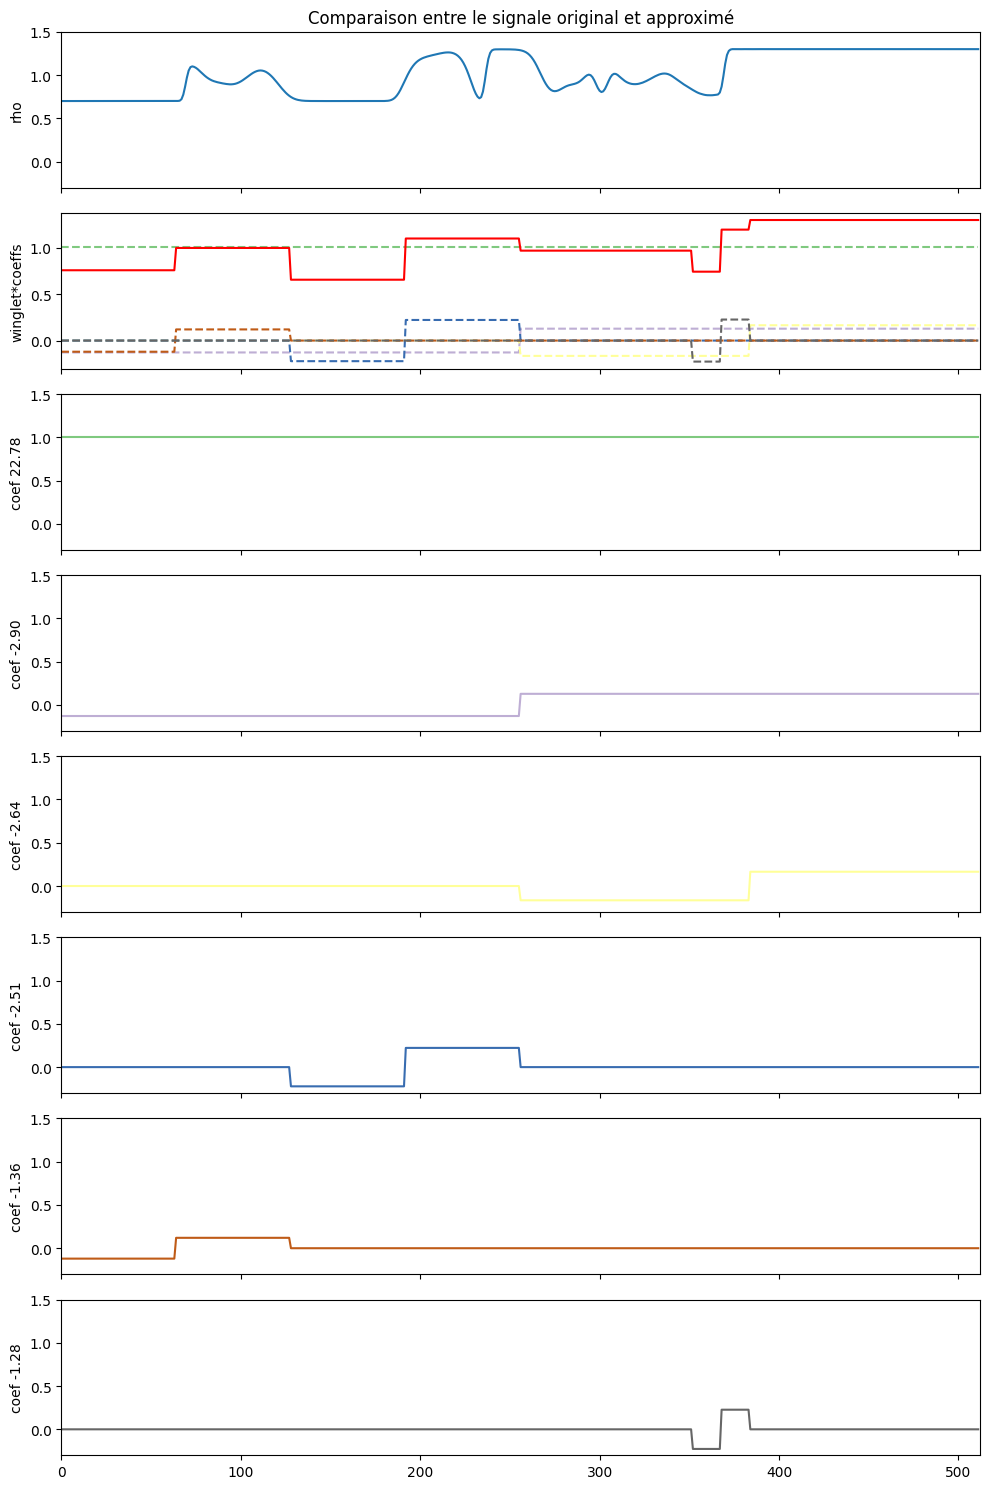

In [ ]:
w = pywt.wavedec(sig, wavelet)

arr, slices = pywt.coeffs_to_array(w)

flat = np.abs(arr).flatten()
idx = np.argsort(flat)
arr_f = np.zeros_like(arr)

arr_f.flat[idx[-M:]] = arr.flat[idx[-M:]]
idx = arr_f.nonzero()[0]
sorted_idx = idx[np.argsort(np.abs(arr_f[idx]))[::-1]]

# -------------------------------------------------------- #
y_supp = 1.5
y_inf  = -0.3
fig, ax = plt.subplots(M+2, 1, figsize=(10, 15), sharex=True)
ax[0].plot(sig)
ax[0].set_xlim(0, sim.shape[1])
ax[0].set_title(f'Comparaison entre le signale original et approximé')
ax[0].set_ylabel("rho")
ax[0].set_ylim(y_inf,y_supp)

colors = plt.cm.Accent(np.linspace(0, 1, M))
wf = np.zeros_like(sig)
print(len(wf))
nb=2
for i in sorted_idx:
    arr_fi = np.zeros_like(arr)

    arr_fi.flat[i] = arr.flat[i]

    coeffs_f = pywt.array_to_coeffs(arr_fi, slices, output_format='wavedec')
    wi = pywt.waverec(coeffs_f, wavelet)
    wf = wf + wi[:len(sig)]

    ax[nb].plot(wi, color=colors[nb-2])
    ax[nb].set_ylabel(f"coef {arr_f[i]:.2f}")
    ax[nb].set_ylim(y_inf,y_supp)

    ax[1].plot(wi, color=colors[nb-2], linestyle="--")

    nb += 1

ax[1].plot(wf, color="red")
ax[1].set_ylabel(f"winglet*coeffs")

plt.tight_layout()
plt.show()
